# Módulo 3: IA Generativa

## Contexto

As autoridades querem relatórios claros e visuais para comunicar com decisores e cidadãos. Pretende-se usar IA Generativa para resumir resultados dos Módulos 1 e 2 e propor recomendações.

## Objetivos de Aprendizagem

1.	Explorar engenharia de prompts para síntese textual;
2.	Criar conteúdos inovadores, mas responsáveis;
3.	Discutir limitações, riscos e implicações socioeconómicas.

## Dados de Entrada
Saídas dos Módulos 1 e 2.

## Tarefas
1.	Desenvolver um script ou notebook gen_report.py que recebe dados em JSON/CSV e gera:
    -  a. resumo executivo (`≤ 200 palavras`);
    -  b. 2-3 recomendações de ação;
    -  c. secção “limitações e riscos”.
2.	Testar ≥ 3 variantes de prompts e comentar diferenças.
3.	Incluir avaliação crítica: transparência, enviesamentos, possíveis “alucinações”.



## Setup

Antes de correr este notebook, deve ter:

1. Um ficheiro `.env` na pasta `Module_3/` com `HF_TOKEN=hf_xxxxxxxxxxxxx` (token de https://huggingface.co/settings/tokens).
2. As bibliotecas instaladas:

```bash
pip install -r ./requirements.txt
```

> **Nota:** Todas as chamadas ao LLM usam o cliente HuggingFace (`Qwen/Qwen2.5-72B-Instruct`).

In [7]:
%pip install python-dotenv huggingface-hub imbalanced-learn

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import dotenv_values
from huggingface_hub import InferenceClient
from markdown_pdf import MarkdownPdf, Section

# Paths — notebook vive em Module_3/, root é o pai
ROOT         = Path("..").resolve()
ALERTS       = ROOT / "Module_1" / "resultados_alertas.csv"
RULES        = ROOT / "Module_1" / "regras.json"
METRICS      = ROOT / "Module_2" / "resultados" / "metrics.csv"
METRICS_COMP = ROOT / "Module_2" / "resultados" / "metrics_comparacao.csv"
DATA_CLEAN   = ROOT / "data" / "clean_air_quality.csv"
PDF_OUTPUT   = ROOT / "resultados_prompts.pdf"

report_pdf = MarkdownPdf(toc_level=2, optimize=True)

MODEL = "Qwen/Qwen2.5-72B-Instruct"

config = dotenv_values(".env")
token  = config.get("HF_TOKEN")
hf_client = InferenceClient(model=MODEL, token=token)

def call_hf(prompt: str, temperature: float = 0.7, max_tokens: int = 800) -> str:
    try:
        r = hf_client.chat_completion(
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=temperature,
        )
        return r.choices[0].message["content"]
    except Exception as e:
        msg = str(e)
        hint = ""
        if "403" in msg or "401" in msg or "permission" in msg.lower() or "authorization" in msg.lower():
            hint = (
                "\n\n💡 Dica: este erro pode dever-se a permissões insuficientes no token do Hugging Face."
                "\n   No menu do token (https://huggingface.co/settings/tokens), certifique-se de que a opção"
                "\n   \"Make calls to Inference Provider\" está ativa."
            )
        raise RuntimeError(f"{msg}{hint}") from e

print("Setup concluído.")

Setup concluído.


## 2. Recolha de Factos dos Módulos Anteriores

**Princípio de grounding:** o LLM nunca vê o dataset bruto. Recebe apenas factos numéricos pré-calculados pelos Módulos 1 e 2. Isto restringe a sua função à formatação textual e mitiga o risco de alucinação — toda a decisão factual continua a vir de código determinístico.

`ReportFacts` e `load_facts` estão definidos abaixo: agregam os três ficheiros de input (alertas, regras, métricas) num único objeto de factos.

In [ ]:
from report_utils import (
    PROMPT_BASELINE, PROMPT_ESTRUTURADO, PROMPT_CRITICO_ETICO,
    PROMPTS, generate_hf, load_facts, ReportFacts
)

facts = load_facts(ALERTS, RULES, METRICS)
print(json.dumps(facts.to_dict(), ensure_ascii=False, indent=2))

print("Utilitários importados de report_utils.py.")

c:\git\IIA_Project\Module_3\report_utils.py:65: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(alerts["datetime"], errors="coerce")


{
  "n_observations": 1442,
  "cities": [
    "Lisboa",
    "Porto"
  ],
  "period": "2025-01-10 a 2025-12-09",
  "alerts_by_level": {
    "NORMAL": 1243,
    "ALTO": 197,
    "MODERADO": 2
  },
  "top_rules": [
    {
      "id": "R04_PM25_ALTO",
      "count": 111,
      "description": "Particulas finas PM2.5 excedem limite anual UE",
      "source": "Diretiva 2008/50/CE (25 ug/m3, anual); WHO 2021 (15 ug/m3, 24h)",
      "action": "Grupos sensiveis permanecam em ambientes internos. Usar mascara FFP2 se necessario."
    },
    {
      "id": "R12_QUALIDADE_AR_PESSIMA",
      "count": 55,
      "description": "Episodio de poluicao multi-poluente com estagnacao",
      "source": "Diretiva 2008/50/CE art. 24 (episodios poluicao); conceito EEA AQI",
      "action": "Qualidade do ar muito degradada agravada por humidade alta. Grupos de risco evitem saídas."
    },
    {
      "id": "R04_PM25_ALTO, R12_QUALIDADE_AR_PESSIMA",
      "count": 24
    },
    {
      "id": "R04_PM25_ALTO, R03_PM10

## 3. Exploração dos Dados de Input

Antes de gerar texto, visualizamos o que o LLM vai receber — é boa prática auditar os factos antes de os injetar no prompt.

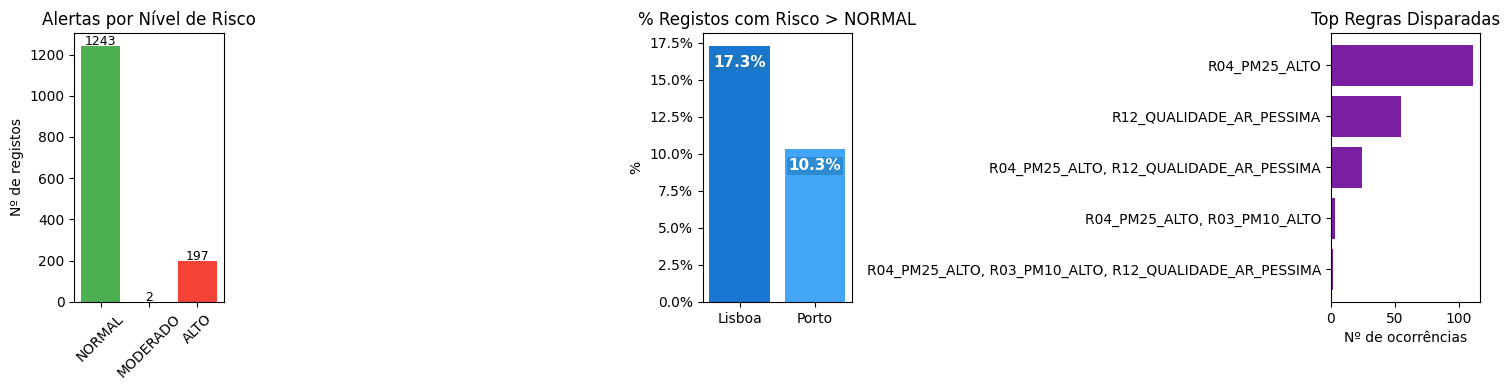

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Gráfico 1: Distribuição de níveis de risco ---
level_order = ["NORMAL", "MODERADO", "ALTO"]
levels = facts.alerts_by_level
counts = [levels.get(l, 0) for l in level_order]
colors = ["#4caf50", "#ff9800", "#f44336"]
axes[0].bar(level_order, counts, color=colors)
axes[0].tick_params(axis="x", rotation=45) # labels inclinados para melhor leitura
axes[0].set_title("Alertas por Nível de Risco")
axes[0].set_ylabel("Nº de registos")
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)

# --- Gráfico 2: % alertas por cidade ---
cities = list(facts.pct_alerts_by_city.keys())
pcts   = list(facts.pct_alerts_by_city.values())
axes[1].bar(cities, pcts, color=["#1976d2", "#42a5f5"])
axes[1].set_title("% Registos com Risco > NORMAL")
axes[1].set_ylabel("%")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
for i, v in enumerate(pcts):
    y_label = max(v - 0.6, 0.2)  # mantém o valor dentro da barra, próximo do topo
    axes[1].text(
        i, y_label, f"{v:.1f}%", ha="center", va="top",
        fontsize=11, fontweight="bold", color="white",
        bbox={"edgecolor": "none", "alpha": 0.55, "pad": 1.2}
    )

# --- Gráfico 3: Top regras disparadas ---
top_rules = facts.top_rules[:5]
rule_ids  = [r["id"] for r in top_rules]
rule_cnts = [r["count"] for r in top_rules]
axes[2].barh(rule_ids[::-1], rule_cnts[::-1], color="#7b1fa2")
axes[2].set_title("Top Regras Disparadas")
axes[2].set_xlabel("Nº de ocorrências")

plt.tight_layout()
plt.show()

In [ ]:
# Tabela de métricas dos modelos 
metrics_df = pd.read_csv(METRICS) # lê o metrics.csv ( correr modulo_2/train_regression.py e modulo_2/train_classification.py para gerar csv atualizado)

print("=== Classificação ===")
cls_cols = ["modelo", "accuracy", "precision", "recall", "f1", "roc_auc"]
display(metrics_df[metrics_df["tarefa"] == "classificacao"][cls_cols].reset_index(drop=True))

print("\n=== Regressão ===")
reg_cols = ["modelo", "r2", "mse", "mae"]
display(metrics_df[metrics_df["tarefa"] == "regressao"][reg_cols].reset_index(drop=True))


=== Classificação ===


,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.8304,0.3438,0.7586,0.4731,0.8533
1,RandomForest,0.9170,0.5641,0.7586,0.6471,0.9366
2,KNN,0.8893,0.4717,0.8621,0.6098,0.9340



=== Regressão ===


,modelo,r2,mse,mae


In [8]:
# Comparação entre variantes do dataset (baseline / sem CO / SMOTE / sem CO + SMOTE)
comp_df = pd.read_csv(METRICS_COMP)
display(comp_df.sort_values(["modelo", "combo"]).reset_index(drop=True))

,combo,modelo,accuracy,precision,recall,f1,roc_auc
0,baseline,KNN,0.9239,0.6842,0.4483,0.5417,0.9127
1,no_co,KNN,0.9239,0.7333,0.3793,0.5000,0.9365
2,no_co_smote,KNN,0.8754,0.4340,0.7931,0.5610,0.9225
3,smote,KNN,0.8893,0.4717,0.8621,0.6098,0.9340
4,baseline,LogisticRegression,0.8304,0.3438,0.7586,0.4731,0.8533
5,no_co,LogisticRegression,0.8270,0.3385,0.7586,0.4681,0.8517
6,no_co_smote,LogisticRegression,0.8201,0.3175,0.6897,0.4348,0.8430
7,smote,LogisticRegression,0.8201,0.3175,0.6897,0.4348,0.8431
8,baseline,RandomForest,0.9204,0.5833,0.7241,0.6462,0.9355
9,no_co,RandomForest,0.9204,0.5882,0.6897,0.6349,0.9373


## 4. Engenharia de Prompts — 3 Variantes

O mesmo objeto `facts` é serializado em JSON e injetado em três prompts distintos. A qualidade e estrutura da saída dependem quase exclusivamente do prompt — os dados são idênticos.

| Variante | Audiência | Restrições explícitas | Tom |
|---|---|---|---|
| Baseline | Genérica | Nenhuma | Livre |
| Estruturado | Proteção Civil (técnico) | Cabeçalhos, limite de palavras, gatilhos quantitativos | Técnico |
| Crítico-Ético | Decisores + cidadãos | Grupos de risco, fontes regulamentares, transparência | Institucional/ético |

### 4.1 Variante 1 — Baseline

Prompt minimalista: pede os três blocos mas não especifica estrutura, tom, nem fonte das alegações. O modelo tem liberdade máxima — o que pode ser útil ou problemático.

In [9]:
print("--- TEMPLATE DO PROMPT BASELINE ---")
print(PROMPT_BASELINE)
print()

--- TEMPLATE DO PROMPT BASELINE ---
És um assistente que escreve relatórios curtos.
A partir destes dados sobre qualidade do ar, escreve:
- Um resumo executivo (≤ 200 palavras)
- 2 a 3 recomendações de ação
- Uma secção sobre limitações e riscos

Dados:
{facts}




In [ ]:
saida_baseline = generate_hf(facts, "baseline", call_hf)
print(saida_baseline)

prompt_baseline_texto = f"""# Baseline

--- TEMPLATE DO PROMPT BASELINE ---

P: {PROMPT_BASELINE}

R: {saida_baseline}
"""
_ = report_pdf.add_section(Section(prompt_baseline_texto))

### Resumo Executivo

O relatório analisa a qualidade do ar nas cidades de Lisboa e Porto durante o período de 10 de janeiro a 9 de dezembro de 2025, com base em 1.442 observações. A maioria das observações (86,2%) registou níveis normais de poluição, enquanto 13,7% foram classificadas como alto e apenas 0,1% como moderado. Lisboa registou uma proporção mais elevada de alertas (17,3%) comparativamente ao Porto (10,3%). As principais regras violadas incluem excedências dos limites anuais da UE para partículas finas PM2.5 e episódios de poluição multi-poluente com estagnação. O modelo RandomForest foi o melhor classificador, com uma precisão de 91,7% e um ROC-AUC de 93,7%.

### Recomendações de Ação

1. **Melhoria da Monitorização e Alerta**: Implementar um sistema de monitorização em tempo real e alerta automático para situações críticas, especialmente em Lisboa, onde os alertas são mais frequentes. Isso permitirá uma resposta mais rápida e eficaz.

2. **Redução de Emissões de Partícula

'<h1>Baseline</h1>\n<p>--- TEMPLATE DO PROMPT BASELINE ---\nP: És um assistente que escreve relatórios curtos.\nA partir destes dados sobre qualidade do ar, escreve:</p>\n<ul>\n<li>Um resumo executivo (≤ 200 palavras)</li>\n<li>2 a 3 recomendações de ação</li>\n<li>Uma secção sobre limitações e riscos</li>\n</ul>\n<p>Dados:\n{facts}</p>\n<p>R: ### Resumo Executivo</p>\n<p>O relatório analisa a qualidade do ar nas cidades de Lisboa e Porto durante o período de 10 de janeiro a 9 de dezembro de 2025, com base em 1.442 observações. A maioria das observações (86,2%) registou níveis normais de poluição, enquanto 13,7% foram classificadas como alto e apenas 0,1% como moderado. Lisboa registou uma proporção mais elevada de alertas (17,3%) comparativamente ao Porto (10,3%). As principais regras violadas incluem excedências dos limites anuais da UE para partículas finas PM2.5 e episódios de poluição multi-poluente com estagnação. O modelo RandomForest foi o melhor classificador, com uma precisão

### 4.2 Variante 2 — Estruturado

Adiciona regras explícitas: cabeçalhos Markdown obrigatórios, limite de 200 palavras no resumo, cada recomendação deve incluir o gatilho quantitativo (ex: `PM2.5 > 25 µg/m³`) e a fonte regulamentar. Proíbe expressamente inventar dados.

In [11]:
print("--- TEMPLATE DO PROMPT ESTRUTURADO ---")
print(PROMPT_ESTRUTURADO)
print()

--- TEMPLATE DO PROMPT ESTRUTURADO ---
És um analista técnico a redigir um relatório para a Proteção Civil. Usa exclusivamente os factos abaixo; não inventes números nem cidades. O relatório tem três secções com cabeçalho em Markdown ('## Resumo executivo', '## Recomendações', '## Limitações e riscos').

Regras:
1. Resumo executivo: máximo 200 palavras, prosa contínua, sem listas.
2. Recomendações: 2 a 3 ações concretas, cada uma indicando o gatilho quantitativo (ex: 'PM10 > 50 µg/m³') e a fonte regulamentar.
3. Limitações e riscos: enumerar pelo menos três limitações dos dados ou modelos, citando as métricas (recall, F1, R²) quando relevante.
4. Se não tiveres informação para uma alegação, escreve 'dados insuficientes'.

Factos:
{facts}




In [ ]:
saida_estruturado = generate_hf(facts, "estruturado", call_hf)
print(saida_estruturado)

prompt_estruturado_texto = f"""# Estruturado

--- TEMPLATE DO PROMPT ESTRUTURADO ---

P: {PROMPT_ESTRUTURADO}

R: {saida_estruturado}
"""
_ = report_pdf.add_section(Section(prompt_estruturado_texto))

## Resumo executivo

O relatório abrange 1.442 observações realizadas entre 10 de janeiro e 9 de dezembro de 2025 nas cidades de Lisboa e Porto. A maioria das observações (86%) registou níveis normais de qualidade do ar, enquanto 13.7% foram classificadas como alto risco, principalmente devido ao excesso de partículas finas PM2.5 acima dos limites da UE e da OMS. Apenas 0.1% das observações foram moderadas. Lisboa registou 17.3% das observações de alerta, contra 10.3% no Porto. Os principais gatilhos de alerta incluem a superação dos limites anuais de PM2.5 e episódios de poluição multi-poluente com estagnação atmosférica. O modelo RandomForest foi o mais preciso na classificação dos alertas, com uma precisão de 56.4% e um recall de 75.9%.

## Recomendações

1. **Ativar Protocolo de Alerta para PM2.5**:
   - Gatilho: PM2.5 > 25 µg/m³ (anual) ou 15 µg/m³ (24h)
   - Fonte: Diretiva 2008/50/CE (25 µg/m³, anual); WHO 2021 (15 µg/m³, 24h)
   - Ação: Grupos sensíveis devem permanecer em ambi

"<h1>Estruturado</h1>\n<p>--- TEMPLATE DO PROMPT ESTRUTURADO ---\nP: És um analista técnico a redigir um relatório para a Proteção Civil. Usa exclusivamente os factos abaixo; não inventes números nem cidades. O relatório tem três secções com cabeçalho em Markdown ('## Resumo executivo', '## Recomendações', '## Limitações e riscos').</p>\n<p>Regras:</p>\n<ol>\n<li>Resumo executivo: máximo 200 palavras, prosa contínua, sem listas.</li>\n<li>Recomendações: 2 a 3 ações concretas, cada uma indicando o gatilho quantitativo (ex: 'PM10 &gt; 50 µg/m³') e a fonte regulamentar.</li>\n<li>Limitações e riscos: enumerar pelo menos três limitações dos dados ou modelos, citando as métricas (recall, F1, R²) quando relevante.</li>\n<li>Se não tiveres informação para uma alegação, escreve 'dados insuficientes'.</li>\n</ol>\n<p>Factos:\n{facts}</p>\n<p>R: ## Resumo executivo</p>\n<p>O relatório abrange 1.442 observações realizadas entre 10 de janeiro e 9 de dezembro de 2025 nas cidades de Lisboa e Porto. 

### 4.3 Variante 3 — Crítico-Ético

Além das restrições estruturais, exige: (i) nomear grupos de risco específicos (asmáticos, idosos, crianças, trabalhadores ao ar livre); (ii) discutir o desbalanço de classes (~10 % registos 'má qualidade'); (iii) mencionar cobertura geográfica limitada; (iv) tratar os modelos como ferramentas de apoio, não como decisores autónomos.

In [ ]:
print("--- TEMPLATE DO PROMPT CRÍTICO-ÉTICO ---")

print(PROMPT_CRITICO_ETICO)

print()

--- TEMPLATE DO PROMPT CRÍTICO-ÉTICO ---
És um analista de políticas públicas a redigir um relatório destinado simultaneamente a decisores municipais e a comunicação ao cidadão. O texto deve ser claro, sem jargão técnico excessivo, em português de Portugal e ético: identifica explicitamente assimetrias de informação, risco de viés e incerteza dos modelos.

Estrutura obrigatória (cabeçalhos em Markdown):
## Resumo executivo (≤ 200 palavras)
## Recomendações (2 a 3 ações)
## Limitações, riscos e considerações éticas

Regras:
1. Usa apenas os factos fornecidos. Se algo não estiver nos factos, diz 'não disponível nos dados deste relatório'.
2. Cada recomendação deve nomear (i) o gatilho quantitativo, (ii) a fonte regulamentar (Diretiva 2008/50/CE, OMS 2021, IPMA), (iii) o grupo de risco específico (asmáticos, idosos, crianças, trabalhadores ao ar livre).
3. Na secção crítica, discute pelo menos: o desbalanço de classes (~10 % de registos 'má'), a cobertura geográfica e sazonal limitada, e 

In [ ]:
saida_critico = generate_hf(facts, "critico_etico", call_hf)
print(saida_critico)

prompt_critico_texto = f"""# Crítico Ético

--- TEMPLATE DO PROMPT CRÍTICO-ÉTICO ---

P: {PROMPT_CRITICO_ETICO}

R: {saida_critico}
"""
_ = report_pdf.add_section(Section(prompt_critico_texto))

## Resumo executivo

Este relatório analisa a qualidade do ar nas cidades de Lisboa e Porto durante o período de 10 de janeiro a 9 de dezembro de 2025. Foram recolhidas 1.442 observações, das quais 1.243 foram classificadas como "NORMAL", 197 como "ALTO" e apenas 2 como "MODERADO". A cidade de Lisboa apresentou uma percentagem mais elevada de alertas (17,3%) comparativamente ao Porto (10,3%). Os principais gatilhos para os alertas foram as partículas finas PM2.5 que excederam o limite anual da União Europeia (UE) e episódios de poluição multi-poluente com estagnação atmosférica. As recomendações focam-se na proteção de grupos sensíveis, como asmáticos, idosos, crianças e trabalhadores ao ar livre, e na melhoria da monitorização e comunicação da qualidade do ar.

## Recomendações

### 1. **Ação em caso de excedência de PM2.5**
   - **Gatilho quantitativo**: Partículas finas PM2.5 excedem 25 µg/m³ (limite anual UE) ou 15 µg/m³ (OMS 2021, 24 horas).
   - **Fonte regulamentar**: Diretiva 2

## 5. Efeito da Temperatura

A temperatura controla a aleatoriedade da distribuição de probabilidade sobre tokens:

- **0.0–0.3** → respostas conservadoras, repetíveis, próximas do mais provável. Ideal para relatórios institucionais.
- **0.4–0.7** → ponto de equilíbrio para tarefas conversacionais.
- **0.8–1.2** → mais criatividade e variedade; útil para brainstorming mas perigoso em contexto factual.

Testamos aqui o efeito no mesmo prompt de síntese, usando o cliente HuggingFace diretamente (modelo Qwen2.5-72B).

In [ ]:
resultados_temperaturas: dict[float,str] = {}
def comparar_temperaturas(prompt: str, temperaturas: list | None = None) -> None:
    if temperaturas is None:
        temperaturas = [0.1, 0.5, 1.0]
    for t in temperaturas:
        print(f"\n{'=' * 60}\nTemperatura: {t}\n{'=' * 60}")
        resultados_temperaturas[t] = call_hf(prompt, temperature=t, max_tokens=300)
        print(resultados_temperaturas[t])


prompt_sintese = f"""Com base nos seguintes factos sobre qualidade do ar em Lisboa e Porto, \
escreve um parágrafo de resumo executivo (máximo 80 palavras) em português europeu.

Factos:
{json.dumps(facts.to_dict(), ensure_ascii=False)}
"""

comparar_temperaturas(prompt_sintese)

prompt_critico_texto = f"""# Comparação de temperaturas

"""
for temp, res in resultados_temperaturas.items(): 
    prompt_critico_texto += f"""
## P: {prompt_sintese}

T: {temp}

R: {res}
"""

_ = report_pdf.add_section(Section(prompt_critico_texto))


Temperatura: 0.1
Durante o período de 10 de janeiro a 9 de dezembro de 2025, foram registadas 1442 observações da qualidade do ar em Lisboa e Porto, com 1243 alertas normais, 197 de nível alto e apenas 2 moderados. Lisboa registou 17,3% dos alertas, contra 10,3% no Porto. Os principais problemas incluíram excedentes de PM2.5 e episódios de poluição multi-poluente. O modelo RandomForest demonstrou ser o mais eficaz na classificação, com uma precisão de 91,7%.

Temperatura: 0.5
Durante o período de 10 de janeiro a 9 de dezembro de 2025, Lisboa e Porto registaram 1442 observações de qualidade do ar, com 1243 níveis normais, 197 altos e apenas 2 moderados. Lisboa teve 17,3% das alertas, contra 10,3% no Porto. Os principais problemas foram partículas finas PM2.5 acima dos limites da UE e episódios de poluição multi-poluente. O modelo RandomForest demonstrou ser o mais eficaz na classificação, com uma precisão de 91,7%.

Temperatura: 1.0
Durante o período de 10 de janeiro a 9 de dezembro de

**Observação:** Para relatórios institucionais sobre qualidade do ar, a temperatura baixa (0.1–0.3) produz texto mais estável e factualmente alinhado. Temperatura alta pode introduzir formulações não suportadas pelos dados — o equivalente textual de uma alucinação subtil.

## 6. Comparação das Variantes

Analisamos automaticamente as três saídas em seis dimensões: comprimento, estrutura, rigor quantitativo, referência a limitações, grupos de risco explícitos e linguagem ética.

In [16]:
def contar_palavras(texto: str) -> int:
    return len(texto.split())

def tem_padrao(texto: str, padrao: str) -> bool:
    return bool(re.search(padrao, texto, re.I | re.UNICODE))

variantes = [
    ("Baseline",      saida_baseline),
    ("Estruturado",   saida_estruturado),
    ("Crítico-Ético", saida_critico),
]

rows = []
for nome, texto in variantes:
    rows.append({
        "Variante":               nome,
        "Palavras":               contar_palavras(texto),
        "Cabeçalhos (##)":        tem_padrao(texto, r"^##"),
        "Gatilhos quantitativos": tem_padrao(texto, r"µg/m|mg/m|\d+\s*%"),
        "Menciona limitações":    tem_padrao(texto, r"limita|restri|cobertura"),
        "Grupos de risco":        tem_padrao(texto, r"asmát|idosos|criança|trabalhador"),
        "Fonte regulamentar":     tem_padrao(texto, r"2008/50|OMS|IPMA|WHO"),
        "Linguagem ética":        tem_padrao(texto, r"vi[eé]s|incertez|transparên|autónomo"),
    })

comp_df = pd.DataFrame(rows).set_index("Variante")
display(comp_df)

,Palavras,Cabeçalhos (##),Gatilhos quantitativos,Menciona limitações,Grupos de risco,Fonte regulamentar,Linguagem ética
Variante,,,,,,,
Baseline,342,True,True,True,True,False,False
Estruturado,342,True,True,True,False,True,False
Crítico-Ético,497,True,True,True,True,True,True


## 7. Avaliação Crítica

### 7.1 Grounding e risco de alucinação

O principal risco dos LLMs em contexto factual é a **alucinação**: o modelo gera texto plausível mas não suportado pelos dados. A célula abaixo demonstra o problema ao enviar o mesmo pedido *sem factos* — o modelo responde com números plausíveis mas inventados.


In [ ]:
prompt_sem_grounding = """Descreve a qualidade do ar em Lisboa e Porto em 2024, \
com dados numéricos sobre PM2.5, NO2 e alertas emitidos."""

print("=== SEM GROUNDING (risco de alucinação) ===")
saida_sem_grounding = call_hf(prompt_sem_grounding, temperature=0.3, max_tokens=300)
print(saida_sem_grounding)

prompt_sem_grounding_texto = f"""# Prompt sem Grounding

--- SEM GROUNDING (risco de alucinação) ---

P: {prompt_sem_grounding}

R: {saida_sem_grounding}
"""
_ = report_pdf.add_section(Section(prompt_sem_grounding_texto))

print("\n" + "=" * 60)
print("=== COM GROUNDING (factos pré-calculados) ===")
prompt_com_grounding = f"""Com base APENAS nos factos abaixo, descreve a qualidade do ar \
em Lisboa e Porto. Não uses dados que não constes nos factos fornecidos.

Factos:
{json.dumps(facts.to_dict(), ensure_ascii=False, indent=2)}
"""
saida_com_grounding = call_hf(prompt_com_grounding, temperature=0.3, max_tokens=300)
print(saida_com_grounding)

prompt_com_grounding_texto = f"""# Prompt com Grounding

--- COM GROUNDING (factos pré-calculados) ---

P: {prompt_com_grounding}

R: {saida_com_grounding}
"""
_ = report_pdf.add_section(Section(prompt_com_grounding_texto))


=== SEM GROUNDING (risco de alucinação) ===
Até o momento, não tenho dados específicos e atualizados para 2024 sobre a qualidade do ar em Lisboa e Porto, pois esses dados ainda estão sendo coletados e analisados. No entanto, posso fornecer uma visão geral baseada em tendências recentes e dados históricos, além de indicar onde você pode encontrar informações mais atualizadas.

### Qualidade do Ar em Lisboa (2023-2024)
- **PM2.5 (Partículas Finas)**: Em 2023, a média anual de PM2.5 em Lisboa variou entre 10 e 15 µg/m³. Para 2024, espera-se que essa média se mantenha dentro desse intervalo, dependendo das condições meteorológicas e das medidas de controle de poluição.
- **NO2 (Dióxido de Azoto)**: A média anual de NO2 em Lisboa em 2023 ficou em torno de 30 a 40 µg/m³. Para 2024, espera-se que essa média permaneça similar, embora haja esforços contínuos para reduzir as emissões de veículos.
- **Alertas Emitidos**: Em 2023, foram emitidos alguns alertas

=== COM GROUNDING (factos pré-calcul

### 7.2 Desbalanço de classes e viés

O modelo ML foi treinado com um dataset desequilibrado: a grande maioria dos registos corresponde a qualidade do ar "boa". Um modelo que preveja sempre "bom" tem precisão elevada mas recall baixo na classe minoritária — o que é inaceitável em saúde pública, onde falsos negativos têm consequências concretas.

Total de registos: 1442
Registos com má qualidade (target=0): 147 (10.2%)
Registos com boa qualidade (target=1): 1295 (89.8%)


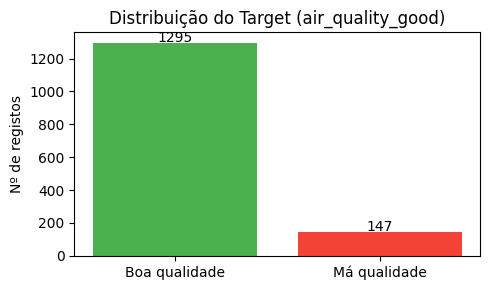

In [18]:
data = pd.read_csv(DATA_CLEAN, sep=";")
n_total = len(data)
n_bad   = (data["air_quality_good"] == 0).sum()
pct_bad = 100 * n_bad / n_total

print(f"Total de registos: {n_total}")
print(f"Registos com má qualidade (target=0): {n_bad} ({pct_bad:.1f}%)")
print(f"Registos com boa qualidade (target=1): {n_total - n_bad} ({100 - pct_bad:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Boa qualidade", "Má qualidade"], [n_total - n_bad, n_bad], color=["#4caf50", "#f44336"])
ax.set_title("Distribuição do Target (air_quality_good)")
ax.set_ylabel("Nº de registos")
for i, v in enumerate([n_total - n_bad, n_bad]):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()

In [19]:
# Recall do melhor classificador na classe minoritária vs. precisão global
metrics = pd.read_csv(METRICS)
cls = metrics[metrics["tarefa"] == "classificacao"].copy()
best = cls.loc[cls["f1"].idxmax()]

print(f"Melhor classificador (maior F1): {best['modelo']}")
print(f"  precisão global : {best['accuracy']:.1%}")
print(f"  Recall (má qualidade): {best['recall']:.1%}")
print(f"  F1              : {best['f1']:.3f}")
print(f"  ROC-AUC         : {best['roc_auc']:.3f}")
print()
print("Implicação: mesmo com precisão >90%, o modelo falha em identificar")
print(f"{100*(1-best['recall']):.0f}% dos episódios reais de má qualidade do ar.")

Melhor classificador (maior F1): RandomForest
  precisão global : 91.7%
  Recall (má qualidade): 75.9%
  F1              : 0.647
  ROC-AUC         : 0.937

Implicação: mesmo com precisão >90%, o modelo falha em identificar
24% dos episódios reais de má qualidade do ar.


### 7.3 Limitações dos dados e dos modelos

| Dimensão | Limitação | Impacto |
|---|---|---|
| **Cobertura geográfica** | Apenas Lisboa e Porto | Não generalizável a cidades interiores ou costeiras |
| **Cobertura temporal** | ~2 meses de dados | Sem sazonalidade completa (verão/inverno) |
| **Definição do target** | `NO₂ ≥ 30 µg/m³ ∧ humidade ≥ 80 %` | Não alinhada com índices oficiais (IQAR) |
| **Desbalanço de classes** | ~10 % registos "má qualidade" | Recall baixo na classe de interesse |
| **Alucinação do LLM** | Modelo pode gerar texto plausível mas não suportado | Grounding obrigatório; validação humana antes de publicar |
| **Autonomia** | Modelos são ferramentas de apoio | Cada alerta deve ser validado pela Proteção Civil |

## 8. Geração do Relatório Final

A função `generate_hf` definida na secção 2 encapsula a construção do prompt e a chamada ao HuggingFace. Aqui demonstramos a geração do relatório final com a variante crítico-ética e gravamos o resultado em Markdown.

In [20]:
report_text = generate_hf(facts, "critico_etico", call_hf)

report_path = Path("report_demo.md")
report_path.write_text(report_text, encoding="utf-8")
print(f"Gerado: {report_path} ({len(report_text)} caracteres, variante=critico_etico)")

# Guardar pdf com as prompts e resultados óbtidos
report_pdf.save(PDF_OUTPUT)

Gerado: report_demo.md (3478 caracteres, variante=critico_etico)


In [21]:
# Mostrar o relatório gerado
report_path = Path("report_demo.md")
if report_path.exists():
    print(report_path.read_text(encoding="utf-8"))
else:
    print("Ficheiro report_demo.md não encontrado — corra a célula anterior primeiro.")

## Resumo executivo

Este relatório analisa a qualidade do ar nas cidades de Lisboa e Porto durante o período de 10 de janeiro a 9 de dezembro de 2025. Foram recolhidas 1.442 observações, das quais 1.243 foram classificadas como "NORMAL", 197 como "ALTO" e apenas 2 como "MODERADO". A maioria dos alertas (111) foi gerada pela regra R04_PM25_ALTO, que indica a superação do limite anual de partículas finas PM2.5 estabelecido pela União Europeia e pela Organização Mundial da Saúde. A cidade de Lisboa registou uma proporção significativamente maior de alertas (17,3%) comparativamente ao Porto (10,3%). Os modelos de classificação utilizados demonstraram uma boa capacidade de predição, com o modelo RandomForest apresentando as melhores métricas de desempenho.

## Recomendações

### 1. **Ação para Partículas Finas PM2.5 Excederem Limite Anual UE**
   - **Gatilho Quantitativo:** Partículas finas PM2.5 excederem 25 µg/m³ (anual) ou 15 µg/m³ (24 horas).
   - **Fonte Regulamentar:** Diretiva 2008/

---

## Conclusões

1. **Engenharia de prompt determina a qualidade da saída.** A variante baseline e a crítico-ética recebem os mesmos factos mas produzem textos com estrutura, rigor e transparência muito diferentes.

2. **Temperatura baixa (≤ 0.3) é essencial para texto institucional.** Temperatura alta introduz variabilidade indesejada e aumenta o risco de formulações não suportadas pelos dados.

3. **Grounding é a principal mitigação de alucinação.** O LLM não deve ter acesso ao dataset bruto; apenas a factos numéricos pré-calculados e verificados por código determinístico.

4. **O desbalanço de classes tem implicações diretas na comunicação pública.** Um recall de ~76 % significa que ~24 % dos episódios reais de má qualidade não seriam detetados — este número deve estar visível em qualquer relatório público.

5. **Os modelos são ferramentas de apoio, não decisores.** Qualquer alerta gerado pelo sistema deve ser validado pela Proteção Civil antes de ser comunicado ao público.